# 08 — Final Evaluation and Analysis

## Goal

This notebook consolidates the complete experimental study.

No new model is trained.

The objectives are to:

1. collect results from all previous notebooks;
2. compare models using validation performance;
3. select the final model without using test performance;
4. report seen and unseen test performance;
5. analyze the contribution of each component;
6. analyze robustness to rotation;
7. analyze robustness to parent-object mask errors;
8. analyze performance as a function of part size;
9. identify representative successes and failures;
10. generate tables and plots for the final report.

---

## Experiments completed

### Baselines

- DINO + CLIP
- DINO + CLIP + parent-object mask

### Geometry

- Object Mask
- Absolute XY
- Relative UV

### Robustness

- rotation
- parent-mask erosion
- parent-mask dilation
- parent-mask translation

### Semantic grounding

- Mask baseline
- Part-query alignment
- Part-query alignment + Relative UV

### Spatial resolution

- Full-image model
- Object-centric crop model
- Small/medium/large part analysis

---

## Experimental Principle

Validation performance determines model selection.

Test results are used only for final reporting.

This avoids selecting a model based on test-set performance.

In [39]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

In [40]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

print("Project root:", PROJECT_ROOT)

Project root: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation


In [41]:
EXPERIMENT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "experiments"
)

BASELINE_ROOT = (
    EXPERIMENT_ROOT
)

GEOMETRY_ROOT = (
    EXPERIMENT_ROOT
    / "geometry"
)

ROBUSTNESS_ROOT = (
    EXPERIMENT_ROOT
    / "robustness"
)

ALIGNMENT_ROOT = (
    EXPERIMENT_ROOT
    / "part_query_alignment"
)

ZOOM_ROOT = (
    EXPERIMENT_ROOT
    / "object_centric_zoom"
)

FINAL_ROOT = (
    EXPERIMENT_ROOT
    / "final_analysis"
)

FINAL_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Final output:", FINAL_ROOT)

Final output: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/final_analysis


In [42]:
expected_files = {

    "baseline_results":
        BASELINE_ROOT
        / "baseline_results.csv",

    "geometry_results":
        GEOMETRY_ROOT
        / "geometry_results.csv",

    "rotation_results":
        ROBUSTNESS_ROOT
        / "rotation_results.csv",

    "mask_robustness":
        ROBUSTNESS_ROOT
        / "mask_robustness_results.csv",

    "alignment_results":
        ALIGNMENT_ROOT
        / "alignment_results.csv",

    "crop_results":
        ZOOM_ROOT
        / "crop_results.csv",

    "part_size_analysis":
        ZOOM_ROOT
        / "part_size_analysis.csv",

    "part_size_summary":
        ZOOM_ROOT
        / "part_size_summary.csv",
}


for name, path in expected_files.items():

    print(
        f"{name:22s}",
        "FOUND"
        if path.exists()
        else "MISSING",
        path,
    )

baseline_results       FOUND /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/baseline_results.csv
geometry_results       FOUND /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/geometry/geometry_results.csv
rotation_results       FOUND /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/robustness/rotation_results.csv
mask_robustness        FOUND /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/robustness/mask_robustness_results.csv
alignment_results      FOUND /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/part_query_alignment/alignment_results.csv
crop_results           FOUND /home/utn/ojug99ek/Computer_Vis

In [43]:
def load_csv_if_exists(path):

    if path.exists():
        return pd.read_csv(path)

    return None


baseline_results = load_csv_if_exists(
    expected_files["baseline_results"]
)

geometry_results = load_csv_if_exists(
    expected_files["geometry_results"]
)

rotation_results = load_csv_if_exists(
    expected_files["rotation_results"]
)

mask_robustness_results = load_csv_if_exists(
    expected_files["mask_robustness"]
)

alignment_results = load_csv_if_exists(
    expected_files["alignment_results"]
)

crop_results = load_csv_if_exists(
    expected_files["crop_results"]
)

part_size_analysis = load_csv_if_exists(
    expected_files["part_size_analysis"]
)

part_size_summary = load_csv_if_exists(
    expected_files["part_size_summary"]
)

print("Result files loaded.")

Result files loaded.


In [44]:
baseline_results

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,DINO + CLIP,0.298047,0.394139,0.140982,0.201020
1,DINO + CLIP + Object Mask,0.311884,0.410370,0.214519,0.297118


In [45]:
geometry_results

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,Object Mask,0.316519,0.417258,0.261346,0.354345
1,Absolute XY,0.318284,0.416771,0.246765,0.339143
2,Relative UV,0.316022,0.414646,0.265248,0.361375


In [46]:
crop_results

,model,seen_iou,unseen_iou
0,Crop Mask Baseline,0.367308,0.276766
1,Crop + Alignment,0.375718,0.329915
2,Crop + Alignment + UV,0.377162,0.321208


# Model Selection

We must not choose the final architecture by looking for the highest
test IoU.

Instead, we reconstruct the validation results from the training histories.

For every trained model:

history.json

contains:

- training loss
- training IoU
- validation loss
- validation IoU
- validation Dice

We take the maximum validation IoU for each model.

The final model is selected using this table only.

Only after the final model has been selected do we inspect its test results.

In [47]:
def read_history(path):

    if not path.exists():

        print(
            "Missing:",
            path
        )

        return None

    with open(
        path,
        "r",
    ) as f:

        history = json.load(f)

    return pd.DataFrame(
        history
    )

In [48]:
candidate_histories = {

    # Notebook 03
    "DINO + CLIP":
        EXPERIMENT_ROOT
        / "part_only"
        / "history.json",

    "DINO + CLIP + Mask":
        EXPERIMENT_ROOT
        / "object_mask"
        / "history.json",


    # Notebook 04
    "Geometry Mask":
        GEOMETRY_ROOT
        / "object_mask"
        / "history.json",

    "Absolute XY":
        GEOMETRY_ROOT
        / "absolute_xy"
        / "history.json",

    "Relative UV":
        GEOMETRY_ROOT
        / "relative_uv"
        / "history.json",


    # Notebook 06
    "Alignment Mask Baseline":
        ALIGNMENT_ROOT
        / "mask_baseline"
        / "history.json",

    "Part-Query Alignment":
        ALIGNMENT_ROOT
        / "alignment_mask"
        / "history.json",

    "Alignment + Relative UV":
        ALIGNMENT_ROOT
        / "alignment_relative_uv"
        / "history.json",


    # Notebook 07
    "Crop Mask Baseline":
        ZOOM_ROOT
        / "mask_baseline"
        / "history.json",

    "Crop + Alignment":
        ZOOM_ROOT
        / "alignment_mask"
        / "history.json",

    "Crop + Alignment + UV":
        ZOOM_ROOT
        / "alignment_relative_uv"
        / "history.json",
}

In [49]:
validation_rows = []

for model_name, path in (
    candidate_histories.items()
):

    history = read_history(
        path
    )

    if history is None:
        continue

    if "val_iou" not in history.columns:
        continue

    best_index = (
        history[
            "val_iou"
        ].idxmax()
    )

    best = history.loc[
        best_index
    ]

    validation_rows.append(
        {
            "model":
                model_name,

            "best_epoch":
                int(
                    best["epoch"]
                ),

            "val_iou":
                float(
                    best["val_iou"]
                ),

            "val_dice":
                float(
                    best["val_dice"]
                )
                if "val_dice"
                in best
                else np.nan,
        }
    )


validation_table = pd.DataFrame(
    validation_rows
)

validation_table = (
    validation_table
    .sort_values(
        "val_iou",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

validation_table

,model,best_epoch,val_iou,val_dice
0,Crop + Alignment + UV,13,0.366283,0.470202
1,Crop + Alignment,13,0.362917,0.468210
2,Crop Mask Baseline,14,0.353602,0.453962
3,Alignment + Relative UV,15,0.310367,0.405732
4,Part-Query Alignment,13,0.308866,0.405876
5,Relative UV,12,0.307839,0.403310
6,Absolute XY,14,0.304110,0.397505
7,Geometry Mask,13,0.301888,0.396554
8,Alignment Mask Baseline,13,0.299327,0.394419
9,DINO + CLIP + Mask,17,0.298462,0.391325


In [50]:
FINAL_MODEL_NAME = (
    validation_table
    .iloc[0]["model"]
)

FINAL_MODEL_VAL_IOU = (
    validation_table
    .iloc[0]["val_iou"]
)

FINAL_MODEL_EPOCH = (
    int(
        validation_table
        .iloc[0]["best_epoch"]
    )
)

print(
    "Selected final model:",
    FINAL_MODEL_NAME
)

print(
    "Validation IoU:",
    FINAL_MODEL_VAL_IOU
)

print(
    "Selected epoch:",
    FINAL_MODEL_EPOCH
)

Selected final model: Crop + Alignment + UV
Validation IoU: 0.36628272473619206
Selected epoch: 13


In [51]:
validation_table.to_csv(
    FINAL_ROOT
    / "model_selection_validation.csv",
    index=False,
)

print(
    "Saved model-selection table."
)

Saved model-selection table.


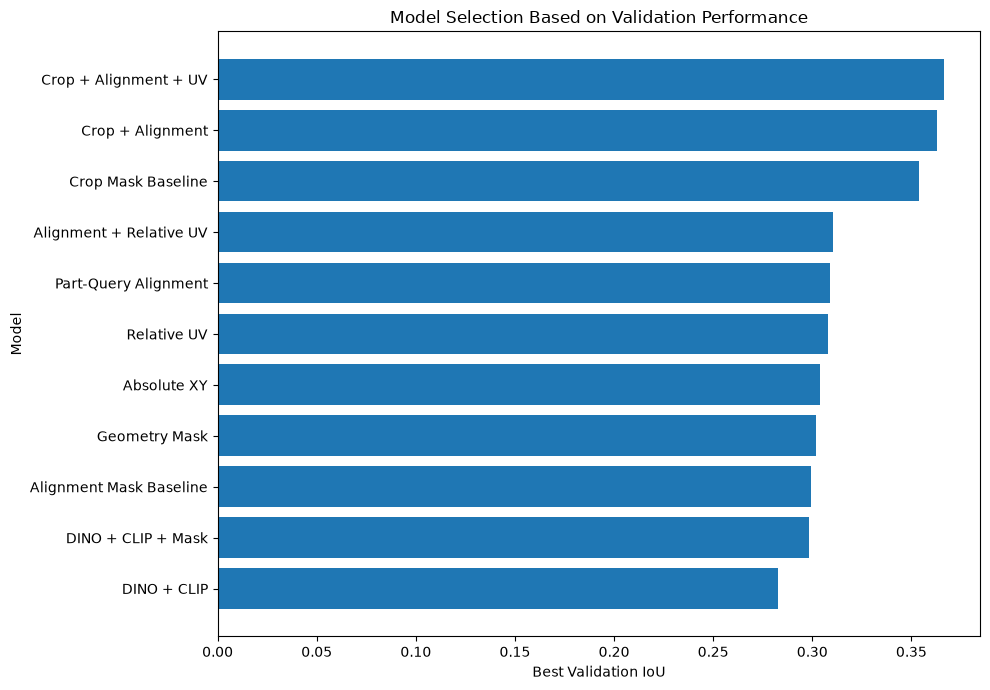

In [52]:
plot_df = (
    validation_table
    .sort_values(
        "val_iou"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    plot_df["model"],
    plot_df["val_iou"],
)

plt.xlabel(
    "Best Validation IoU"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Model Selection Based on Validation Performance"
)

plt.tight_layout()

plt.show()

In [53]:
progression_rows = []

In [54]:
if baseline_results is not None:

    for _, row in (
        baseline_results.iterrows()
    ):

        progression_rows.append(
            {
                "stage":
                    "Baseline",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )
if geometry_results is not None:

    for _, row in (
        geometry_results.iterrows()
    ):

        progression_rows.append(
            {
                "stage":
                    "Geometry",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )

if alignment_results is not None:

    for _, row in (
        alignment_results.iterrows()
    ):

        progression_rows.append(
            {
                "stage":
                    "Alignment",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )
if crop_results is not None:

    for _, row in (
        crop_results.iterrows()
    ):

        progression_rows.append(
            {
                "stage":
                    "Object Zoom",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )


progression_table = pd.DataFrame(
    progression_rows
)

progression_table

,stage,model,seen_iou,unseen_iou
0,Baseline,DINO + CLIP,0.298047,0.140982
1,Baseline,DINO + CLIP + Object Mask,0.311884,0.214519
2,Geometry,Object Mask,0.316519,0.261346
3,Geometry,Absolute XY,0.318284,0.246765
4,Geometry,Relative UV,0.316022,0.265248
5,Alignment,Mask baseline,0.310237,0.196982
6,Alignment,Part-query alignment,0.318711,0.268927
7,Alignment,Alignment + Relative UV,0.320544,0.265908
8,Object Zoom,Crop Mask Baseline,0.367308,0.276766
9,Object Zoom,Crop + Alignment,0.375718,0.329915


## Comparison Caution

Not every row in the progression table is a perfectly controlled ablation.

For example:

- Notebook 03 and Notebook 04 use slightly different decoder input sizes.
- Notebook 06 introduces a different shared projection structure.
- Notebook 07 changes the input view itself.

Therefore:

### Controlled claims

should come from comparisons inside the same notebook.

Examples:

Object Mask vs Absolute XY vs Relative UV

and

Mask Baseline vs Alignment vs Alignment + UV.

### Cross-notebook comparisons

are useful for understanding the overall system progression, but should not
be described as single-variable ablations unless all other architecture and
training settings are identical.

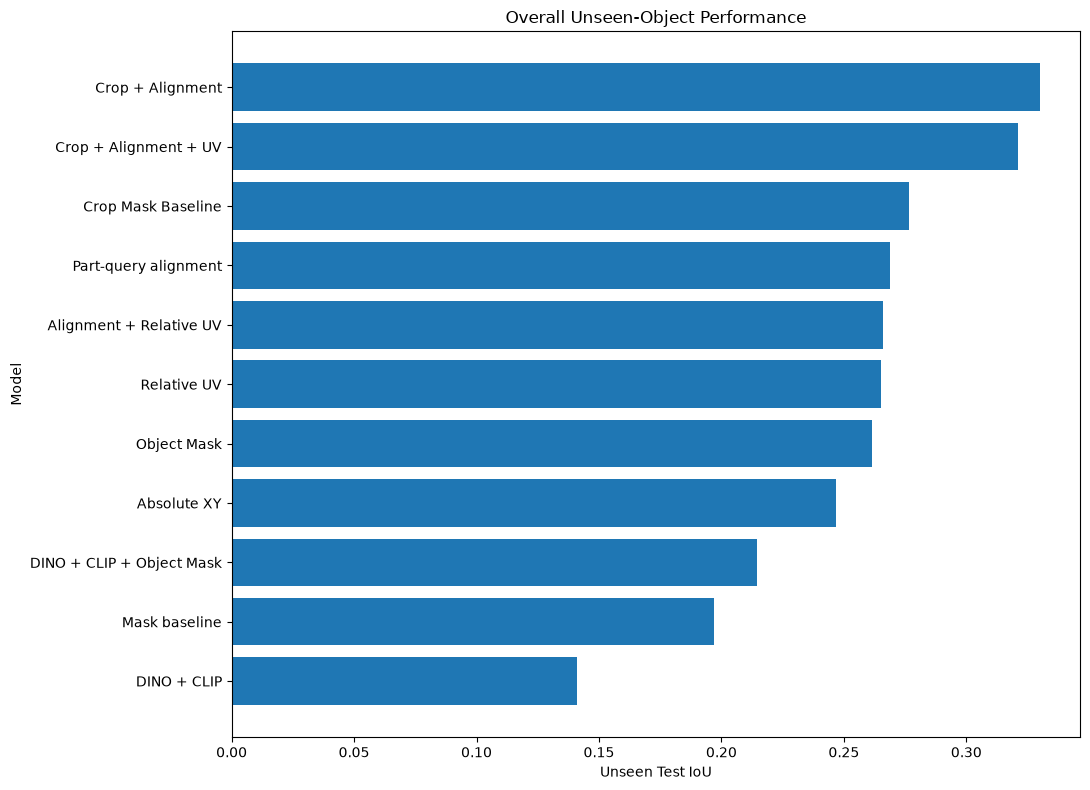

In [55]:
plot_df = (
    progression_table
    .sort_values(
        "unseen_iou"
    )
)

plt.figure(
    figsize=(11, 8)
)

plt.barh(
    plot_df["model"],
    plot_df["unseen_iou"],
)

plt.xlabel(
    "Unseen Test IoU"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Overall Unseen-Object Performance"
)

plt.tight_layout()

plt.show()

In [56]:
if baseline_results is not None:

    display(
        baseline_results
    )

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,DINO + CLIP,0.298047,0.394139,0.140982,0.201020
1,DINO + CLIP + Object Mask,0.311884,0.410370,0.214519,0.297118


In [57]:
if baseline_results is not None:

    baseline_row = (
        baseline_results.iloc[0]
    )

    object_row = (
        baseline_results.iloc[1]
    )

    mask_seen_gain = (
        object_row["seen_iou"]
        - baseline_row["seen_iou"]
    )

    mask_unseen_gain = (
        object_row["unseen_iou"]
        - baseline_row["unseen_iou"]
    )

    print(
        "Parent-object mask gain"
    )

    print(
        f"Seen:   "
        f"{mask_seen_gain:+.4f}"
    )

    print(
        f"Unseen: "
        f"{mask_unseen_gain:+.4f}"
    )

Parent-object mask gain
Seen:   +0.0138
Unseen: +0.0735


In [58]:
if geometry_results is not None:

    display(
        geometry_results
    )

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,Object Mask,0.316519,0.417258,0.261346,0.354345
1,Absolute XY,0.318284,0.416771,0.246765,0.339143
2,Relative UV,0.316022,0.414646,0.265248,0.361375


In [59]:
if geometry_results is not None:

    geometry_lookup = (
        geometry_results
        .set_index(
            "model"
        )
    )


    object_unseen = (
        geometry_lookup.loc[
            "Object Mask",
            "unseen_iou",
        ]
    )


    xy_unseen = (
        geometry_lookup.loc[
            "Absolute XY",
            "unseen_iou",
        ]
    )


    uv_unseen = (
        geometry_lookup.loc[
            "Relative UV",
            "unseen_iou",
        ]
    )


    print(
        "Absolute XY vs Mask:",
        f"{xy_unseen - object_unseen:+.4f}"
    )


    print(
        "Relative UV vs Mask:",
        f"{uv_unseen - object_unseen:+.4f}"
    )


    print(
        "Relative UV vs Absolute XY:",
        f"{uv_unseen - xy_unseen:+.4f}"
    )

Absolute XY vs Mask: -0.0146
Relative UV vs Mask: +0.0039
Relative UV vs Absolute XY: +0.0185


In [60]:
if geometry_results is not None:

    display(
        geometry_results
    )

,model,seen_iou,seen_dice,unseen_iou,unseen_dice
0,Object Mask,0.316519,0.417258,0.261346,0.354345
1,Absolute XY,0.318284,0.416771,0.246765,0.339143
2,Relative UV,0.316022,0.414646,0.265248,0.361375


In [61]:
if geometry_results is not None:

    geometry_lookup = (
        geometry_results
        .set_index(
            "model"
        )
    )


    object_unseen = (
        geometry_lookup.loc[
            "Object Mask",
            "unseen_iou",
        ]
    )


    xy_unseen = (
        geometry_lookup.loc[
            "Absolute XY",
            "unseen_iou",
        ]
    )


    uv_unseen = (
        geometry_lookup.loc[
            "Relative UV",
            "unseen_iou",
        ]
    )


    print(
        "Absolute XY vs Mask:",
        f"{xy_unseen - object_unseen:+.4f}"
    )


    print(
        "Relative UV vs Mask:",
        f"{uv_unseen - object_unseen:+.4f}"
    )


    print(
        "Relative UV vs Absolute XY:",
        f"{uv_unseen - xy_unseen:+.4f}"
    )

Absolute XY vs Mask: -0.0146
Relative UV vs Mask: +0.0039
Relative UV vs Absolute XY: +0.0185


In [62]:
if geometry_results is not None:

    tolerance = 0.005

    uv_gain = (
        uv_unseen
        - object_unseen
    )

    xy_gain = (
        xy_unseen
        - object_unseen
    )

    uv_over_xy = (
        uv_unseen
        - xy_unseen
    )


    if (
        uv_gain > tolerance
        and uv_over_xy > tolerance
    ):

        geometry_interpretation = (
            "Relative UV improves over both the "
            "mask-only baseline and absolute XY. "
            "This supports the hypothesis that "
            "the object-relative reference frame "
            "provides complementary spatial information."
        )


    elif (
        uv_gain > tolerance
        and abs(
            uv_over_xy
        ) <= tolerance
    ):

        geometry_interpretation = (
            "Explicit coordinates improve performance, "
            "but Relative UV and Absolute XY are similar. "
            "The main benefit appears to come from explicit "
            "position rather than the object-relative "
            "coordinate system itself."
        )


    elif (
        abs(uv_gain) <= tolerance
        and abs(xy_gain) <= tolerance
    ):

        geometry_interpretation = (
            "Neither coordinate representation provides "
            "a substantial improvement over the mask-only "
            "baseline. This suggests that DINOv2 already "
            "contains much of the useful spatial information."
        )


    elif uv_gain < -tolerance:

        geometry_interpretation = (
            "Relative UV reduces performance. "
            "The explicit object-relative prior may introduce "
            "a spatial bias that is not consistently valid "
            "across object poses and appearances."
        )


    else:

        geometry_interpretation = (
            "The geometry results are mixed and should be "
            "interpreted together with the robustness tests."
        )


    print(
        geometry_interpretation
    )

The geometry results are mixed and should be interpreted together with the robustness tests.


In [63]:
if alignment_results is not None:

    display(
        alignment_results
    )

,model,seen_iou,seen_dice,unseen_iou,unseen_dice,unseen_alignment_iou
0,Mask baseline,0.310237,0.409657,0.196982,0.273686,0.151813
1,Part-query alignment,0.318711,0.420098,0.268927,0.365683,0.496710
2,Alignment + Relative UV,0.320544,0.419953,0.265908,0.359352,0.499427


In [64]:
if alignment_results is not None:

    alignment_lookup = (
        alignment_results
        .set_index(
            "model"
        )
    )


    alignment_base = (
        alignment_lookup.loc[
            "Mask baseline",
            "unseen_iou",
        ]
    )


    alignment_only = (
        alignment_lookup.loc[
            "Part-query alignment",
            "unseen_iou",
        ]
    )


    alignment_uv = (
        alignment_lookup.loc[
            "Alignment + Relative UV",
            "unseen_iou",
        ]
    )


    print(
        "Alignment gain:",
        f"{alignment_only - alignment_base:+.4f}"
    )


    print(
        "UV gain after alignment:",
        f"{alignment_uv - alignment_only:+.4f}"
    )

Alignment gain: +0.0719
UV gain after alignment: -0.0030


In [65]:
if alignment_results is not None:

    alignment_gain = (
        alignment_only
        - alignment_base
    )

    uv_after_alignment = (
        alignment_uv
        - alignment_only
    )

    tolerance = 0.005


    if (
        alignment_gain > tolerance
        and uv_after_alignment > tolerance
    ):

        alignment_interpretation = (
            "Explicit part-query alignment improves unseen-object "
            "segmentation, and Relative UV provides additional gain. "
            "Semantic grounding and object-relative geometry appear "
            "complementary."
        )


    elif (
        alignment_gain > tolerance
        and abs(
            uv_after_alignment
        ) <= tolerance
    ):

        alignment_interpretation = (
            "Explicit part-query alignment improves segmentation, "
            "while Relative UV adds little afterward. "
            "This suggests semantic grounding is a more important "
            "bottleneck than missing coordinate information."
        )


    elif abs(
        alignment_gain
    ) <= tolerance:

        alignment_interpretation = (
            "Explicit part-query alignment provides little additional "
            "performance. The existing decoder may already learn much "
            "of the required correspondence between DINO and CLIP."
        )


    else:

        alignment_interpretation = (
            "The explicit alignment branch reduces performance, "
            "indicating that the auxiliary correspondence objective "
            "may constrain the representation too strongly."
        )


    print(
        alignment_interpretation
    )

Explicit part-query alignment improves segmentation, while Relative UV adds little afterward. This suggests semantic grounding is a more important bottleneck than missing coordinate information.


In [66]:
if rotation_results is not None:

    unseen_rotation = (
        rotation_results[
            rotation_results[
                "split"
            ]
            == "unseen"
        ]
    )


    rotation_pivot = (
        unseen_rotation
        .pivot(
            index="angle",
            columns="model",
            values="iou",
        )
    )


    rotation_pivot

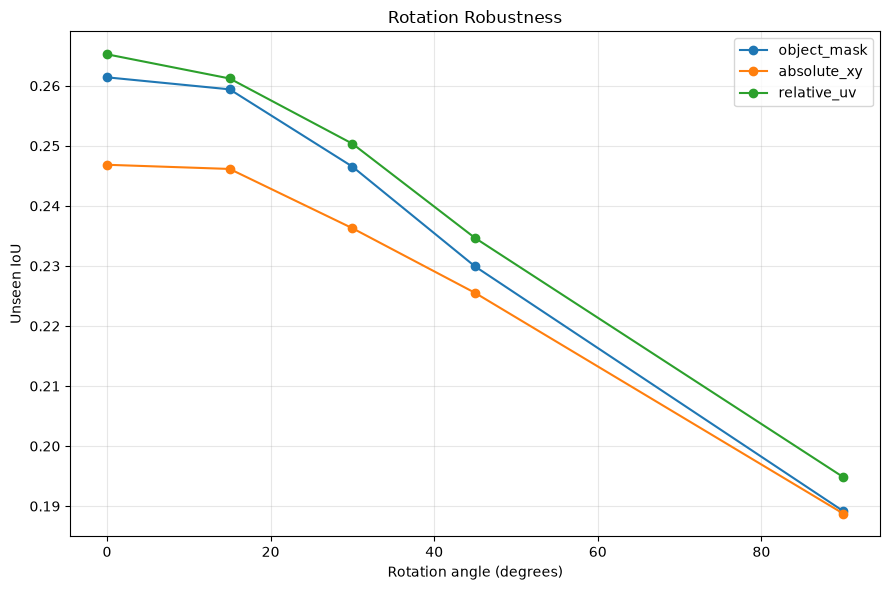

In [67]:
if rotation_results is not None:

    plt.figure(
        figsize=(9, 6)
    )


    for model in (
        unseen_rotation[
            "model"
        ].unique()
    ):

        subset = (
            unseen_rotation[
                unseen_rotation[
                    "model"
                ]
                == model
            ]
            .sort_values(
                "angle"
            )
        )


        plt.plot(
            subset["angle"],
            subset["iou"],
            marker="o",
            label=model,
        )


    plt.xlabel(
        "Rotation angle (degrees)"
    )

    plt.ylabel(
        "Unseen IoU"
    )

    plt.title(
        "Rotation Robustness"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

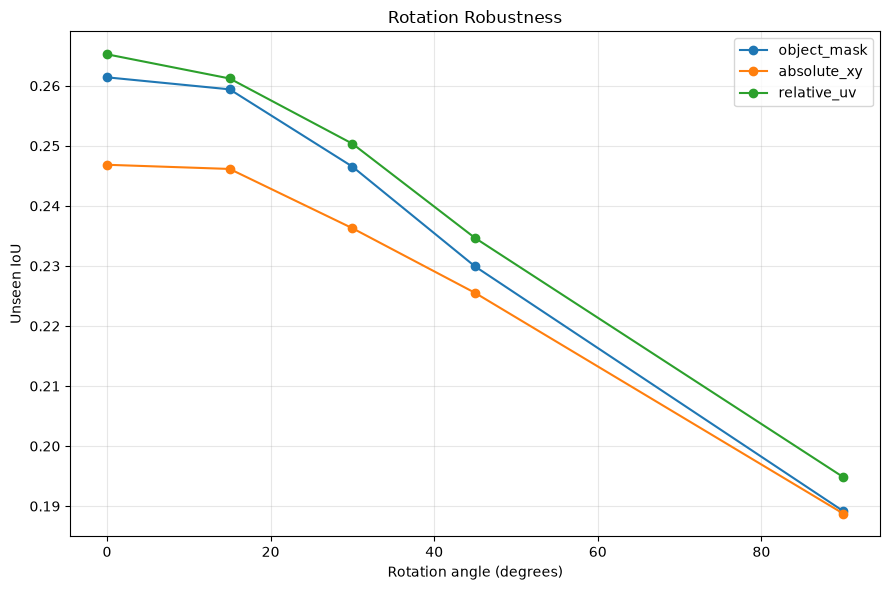

In [68]:
if rotation_results is not None:

    plt.figure(
        figsize=(9, 6)
    )


    for model in (
        unseen_rotation[
            "model"
        ].unique()
    ):

        subset = (
            unseen_rotation[
                unseen_rotation[
                    "model"
                ]
                == model
            ]
            .sort_values(
                "angle"
            )
        )


        plt.plot(
            subset["angle"],
            subset["iou"],
            marker="o",
            label=model,
        )


    plt.xlabel(
        "Rotation angle (degrees)"
    )

    plt.ylabel(
        "Unseen IoU"
    )

    plt.title(
        "Rotation Robustness"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [69]:
rotation_drop_rows = []


if rotation_results is not None:

    for model in (
        unseen_rotation[
            "model"
        ].unique()
    ):

        subset = (
            unseen_rotation[
                unseen_rotation[
                    "model"
                ]
                == model
            ]
        )


        zero_iou = (
            subset[
                subset[
                    "angle"
                ]
                == 0
            ][
                "iou"
            ]
            .iloc[0]
        )


        for _, row in (
            subset.iterrows()
        ):

            rotation_drop_rows.append(
                {
                    "model":
                        model,

                    "angle":
                        row["angle"],

                    "iou":
                        row["iou"],

                    "absolute_drop":
                        row["iou"]
                        - zero_iou,

                    "relative_retention":
                        row["iou"]
                        / max(
                            zero_iou,
                            1e-8,
                        ),
                }
            )


rotation_drop_table = pd.DataFrame(
    rotation_drop_rows
)

rotation_drop_table

,model,angle,iou,absolute_drop,relative_retention
0,object_mask,0,0.261407,0.000000,1.000000
1,object_mask,15,0.259403,-0.002003,0.992336
2,object_mask,30,0.246539,-0.014868,0.943124
3,object_mask,45,0.229909,-0.031498,0.879505
4,object_mask,90,0.189173,-0.072234,0.723672
5,absolute_xy,0,0.246844,0.000000,1.000000
6,absolute_xy,15,0.246149,-0.000696,0.997181
7,absolute_xy,30,0.236279,-0.010566,0.957198
8,absolute_xy,45,0.225508,-0.021337,0.913563
9,absolute_xy,90,0.188765,-0.058080,0.764711


In [70]:
if len(
    rotation_drop_table
) > 0:

    rotation_90 = (
        rotation_drop_table[
            rotation_drop_table[
                "angle"
            ]
            == 90
        ][
            [
                "model",
                "iou",
                "absolute_drop",
                "relative_retention",
            ]
        ]
        .sort_values(
            "absolute_drop",
            ascending=False,
        )
    )

    rotation_90

In [71]:
if mask_robustness_results is not None:

    unseen_mask = (
        mask_robustness_results[
            mask_robustness_results[
                "split"
            ]
            == "unseen"
        ]
    )

    display(
        unseen_mask[
            [
                "condition",
                "model",
                "conditioning_mask_iou",
                "iou",
                "iou_drop_from_clean",
            ]
        ]
    )

,condition,model,conditioning_mask_iou,iou,iou_drop_from_clean
21,clean,object_mask,1.000000,0.261395,0.000000
22,clean,absolute_xy,1.000000,0.246843,0.000000
23,clean,relative_uv,1.000000,0.265243,0.000000
24,erode_5,object_mask,0.732524,0.250667,-0.010728
25,erode_5,absolute_xy,0.732524,0.229513,-0.017330
26,erode_5,relative_uv,0.732524,0.244861,-0.020382
27,erode_11,object_mask,0.488379,0.223877,-0.037518
28,erode_11,absolute_xy,0.488379,0.188475,-0.058368
29,erode_11,relative_uv,0.488379,0.202155,-0.063088
30,dilate_5,object_mask,0.780548,0.267953,0.006558


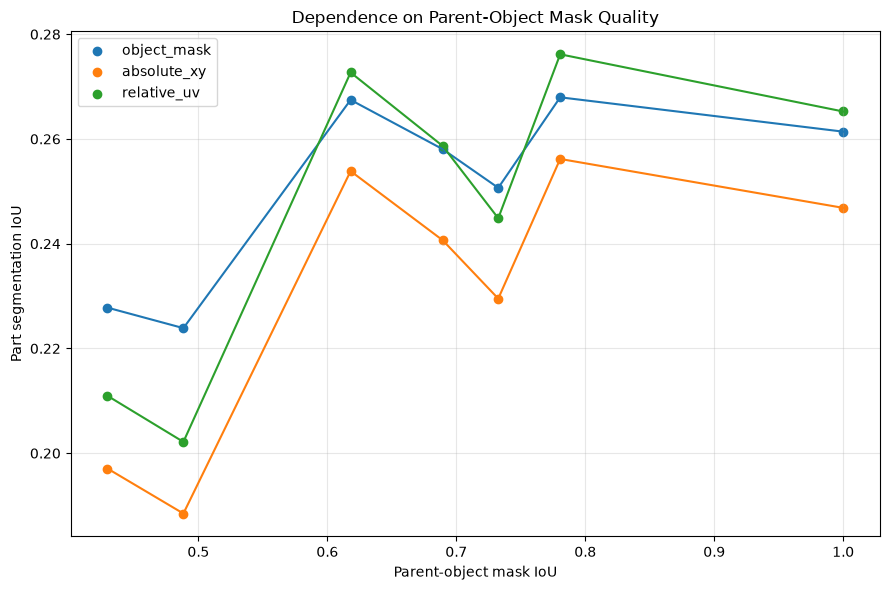

In [72]:
if mask_robustness_results is not None:

    plt.figure(
        figsize=(9, 6)
    )


    for model in (
        unseen_mask[
            "model"
        ].unique()
    ):

        subset = (
            unseen_mask[
                unseen_mask[
                    "model"
                ]
                == model
            ]
        )


        plt.scatter(
            subset[
                "conditioning_mask_iou"
            ],
            subset[
                "iou"
            ],
            label=model,
        )


        ordered = (
            subset.sort_values(
                "conditioning_mask_iou"
            )
        )


        plt.plot(
            ordered[
                "conditioning_mask_iou"
            ],
            ordered[
                "iou"
            ],
        )


    plt.xlabel(
        "Parent-object mask IoU"
    )

    plt.ylabel(
        "Part segmentation IoU"
    )

    plt.title(
        "Dependence on Parent-Object Mask Quality"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

In [73]:
if mask_robustness_results is not None:

    worst_condition_rows = []


    for model in (
        unseen_mask[
            "model"
        ].unique()
    ):

        subset = (
            unseen_mask[
                unseen_mask[
                    "model"
                ]
                == model
            ]
        )


        clean = (
            subset[
                subset[
                    "condition"
                ]
                == "clean"
            ]["iou"]
            .iloc[0]
        )


        minimum_row = (
            subset.loc[
                subset[
                    "iou"
                ].idxmin()
            ]
        )


        worst_condition_rows.append(
            {
                "model":
                    model,

                "clean_iou":
                    clean,

                "worst_condition":
                    minimum_row[
                        "condition"
                    ],

                "worst_iou":
                    minimum_row[
                        "iou"
                    ],

                "drop":
                    minimum_row[
                        "iou"
                    ]
                    - clean,
            }
        )


    mask_sensitivity = (
        pd.DataFrame(
            worst_condition_rows
        )
    )


    mask_sensitivity

In [74]:
if part_size_summary is not None:

    part_size_summary

In [75]:
if part_size_summary is not None:

    part_size_summary = (
        part_size_summary
        .rename(
            columns={
                part_size_summary.columns[0]:
                    "size_group"
            }
        )
    )

    part_size_summary

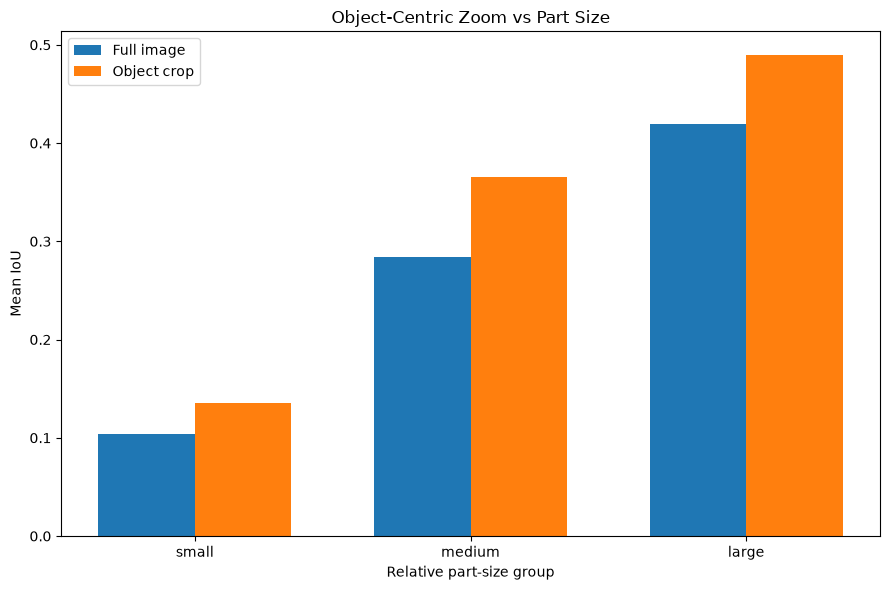

In [76]:
if part_size_summary is not None:

    groups = (
        part_size_summary[
            "size_group"
        ]
    )


    x = np.arange(
        len(groups)
    )

    width = 0.35


    plt.figure(
        figsize=(9, 6)
    )


    plt.bar(
        x - width / 2,
        part_size_summary[
            "full_iou"
        ],
        width,
        label="Full image",
    )


    plt.bar(
        x + width / 2,
        part_size_summary[
            "crop_iou"
        ],
        width,
        label="Object crop",
    )


    plt.xticks(
        x,
        groups,
    )

    plt.ylabel(
        "Mean IoU"
    )

    plt.xlabel(
        "Relative part-size group"
    )

    plt.title(
        "Object-Centric Zoom vs Part Size"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

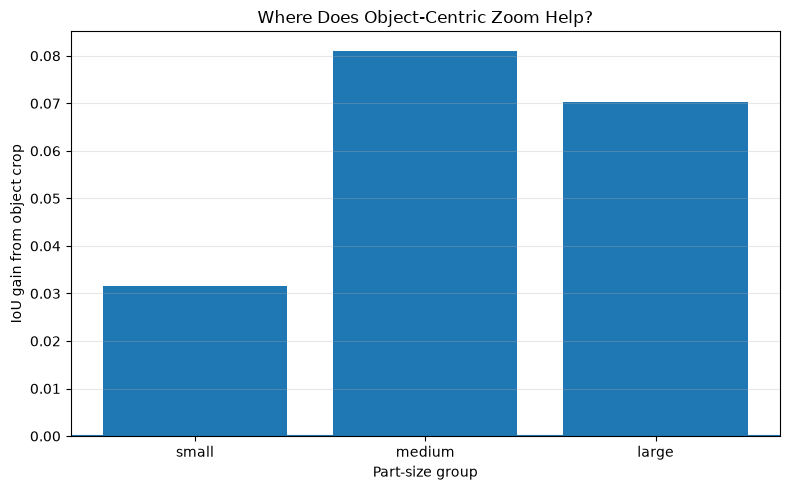

In [77]:
if part_size_summary is not None:

    plt.figure(
        figsize=(8, 5)
    )


    plt.bar(
        part_size_summary[
            "size_group"
        ],
        part_size_summary[
            "mean_gain"
        ],
    )


    plt.axhline(
        0
    )


    plt.xlabel(
        "Part-size group"
    )

    plt.ylabel(
        "IoU gain from object crop"
    )

    plt.title(
        "Where Does Object-Centric Zoom Help?"
    )

    plt.grid(
        axis="y",
        alpha=0.3,
    )

    plt.tight_layout()

    plt.show()

In [78]:
if part_size_summary is not None:

    size_lookup = (
        part_size_summary
        .set_index(
            "size_group"
        )
    )


    if (
        "small"
        in size_lookup.index
        and "large"
        in size_lookup.index
    ):

        small_gain = (
            size_lookup.loc[
                "small",
                "mean_gain",
            ]
        )

        large_gain = (
            size_lookup.loc[
                "large",
                "mean_gain",
            ]
        )


        print(
            "Small-part crop gain:",
            f"{small_gain:+.4f}"
        )

        print(
            "Large-part crop gain:",
            f"{large_gain:+.4f}"
        )

        print(
            "Difference:",
            f"{small_gain - large_gain:+.4f}"
        )

Small-part crop gain: +0.0316
Large-part crop gain: +0.0703
Difference: -0.0386


In [79]:
if part_size_analysis is not None:

    best_crop_examples = (
        part_size_analysis
        .sort_values(
            "gain",
            ascending=False,
        )
        .head(15)
    )


    display(
        best_crop_examples[
            [
                "sample_id",
                "object",
                "part",
                "part_ratio",
                "full_iou",
                "crop_iou",
                "gain",
            ]
        ]
    )

,sample_id,object,part,part_ratio,full_iou,crop_iou,gain
512,val:2009_000989:part_66,dog,nose,0.010230,6.249999e-08,0.800000,0.800000
425,val:2009_000156:part_63,dog,torso,0.624609,3.338900e-03,0.785489,0.782150
185,val:2008_003141:part_41,car,window,0.167054,7.651109e-10,0.768041,0.768041
1161,val:2010_001563:part_63,dog,torso,0.467290,9.756102e-03,0.777293,0.767536
1464,val:2010_005013:part_32,car,wheel,0.064121,1.123596e-08,0.760870,0.760870
298,val:2008_006526:part_36,car,back,0.728814,5.813953e-09,0.728972,0.728972
1301,val:2010_003231:part_37,car,roof,0.080967,2.915452e-09,0.718182,0.718182
1021,val:2010_000502:part_13,bird,head,0.049505,2.439024e-08,0.714286,0.714286
231,val:2008_004339:part_32,car,wheel,0.160448,7.751938e-09,0.692810,0.692810
821,val:2009_004070:part_101,sheep,eye,0.009677,2.500000e-08,0.666667,0.666667


In [80]:
if part_size_analysis is not None:

    worst_crop_examples = (
        part_size_analysis
        .sort_values(
            "gain",
            ascending=True,
        )
        .head(15)
    )


    display(
        worst_crop_examples[
            [
                "sample_id",
                "object",
                "part",
                "part_ratio",
                "full_iou",
                "crop_iou",
                "gain",
            ]
        ]
    )

,sample_id,object,part,part_ratio,full_iou,crop_iou,gain
1477,val:2010_005159:part_68,dog,ear,0.099290,0.679127,1.871298e-01,-0.491997
148,val:2008_002859:part_66,dog,nose,0.004707,0.473118,5.952381e-09,-0.473118
1034,val:2010_000530:part_41,car,window,0.166780,0.466089,1.721170e-09,-0.466089
1209,val:2010_001995:part_15,bird,beak,0.029682,0.465267,2.409638e-09,-0.465267
207,val:2008_003576:part_63,dog,torso,0.492594,0.668739,2.137528e-01,-0.454986
1265,val:2010_002988:part_41,car,window,0.164840,0.562173,1.096606e-01,-0.452512
225,val:2008_003846:part_41,car,window,0.144823,0.524059,9.598330e-02,-0.428076
1062,val:2010_000814:part_14,bird,eye,0.002030,0.457143,3.125001e-02,-0.425893
227,val:2008_004069:part_33,car,headlight,0.035071,0.607080,1.883117e-01,-0.418768
1528,val:2010_005501:part_41,car,window,0.228519,0.595445,1.813422e-01,-0.414103


In [81]:
progression_table[
    "seen_unseen_gap"
] = (
    progression_table[
        "seen_iou"
    ]
    -
    progression_table[
        "unseen_iou"
    ]
)


gap_table = (
    progression_table[
        [
            "stage",
            "model",
            "seen_iou",
            "unseen_iou",
            "seen_unseen_gap",
        ]
    ]
    .sort_values(
        "seen_unseen_gap"
    )
)


gap_table

,stage,model,seen_iou,unseen_iou,seen_unseen_gap
9,Object Zoom,Crop + Alignment,0.375718,0.329915,0.045803
6,Alignment,Part-query alignment,0.318711,0.268927,0.049784
4,Geometry,Relative UV,0.316022,0.265248,0.050774
7,Alignment,Alignment + Relative UV,0.320544,0.265908,0.054636
2,Geometry,Object Mask,0.316519,0.261346,0.055173
10,Object Zoom,Crop + Alignment + UV,0.377162,0.321208,0.055954
3,Geometry,Absolute XY,0.318284,0.246765,0.071519
8,Object Zoom,Crop Mask Baseline,0.367308,0.276766,0.090542
1,Baseline,DINO + CLIP + Object Mask,0.311884,0.214519,0.097365
5,Alignment,Mask baseline,0.310237,0.196982,0.113256


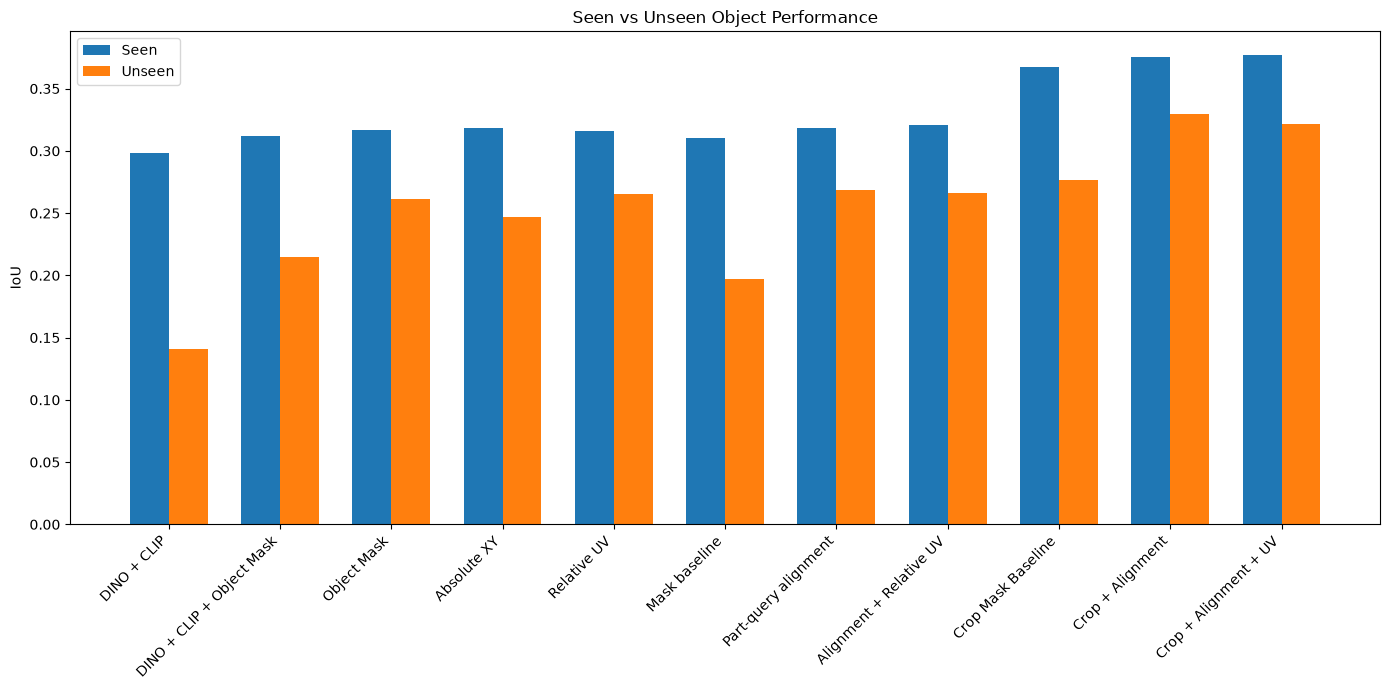

In [82]:
plot_df = (
    progression_table
    .copy()
)

x = np.arange(
    len(plot_df)
)

width = 0.35


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    x - width / 2,
    plot_df[
        "seen_iou"
    ],
    width,
    label="Seen",
)


plt.bar(
    x + width / 2,
    plot_df[
        "unseen_iou"
    ],
    width,
    label="Unseen",
)


plt.xticks(
    x,
    plot_df[
        "model"
    ],
    rotation=45,
    ha="right",
)


plt.ylabel(
    "IoU"
)

plt.title(
    "Seen vs Unseen Object Performance"
)

plt.legend()

plt.tight_layout()

plt.show()

In [83]:
ablation_rows = []

if geometry_results is not None:

    for _, row in (
        geometry_results.iterrows()
    ):

        ablation_rows.append(
            {
                "study":
                    "Coordinate system",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )
if alignment_results is not None:

    for _, row in (
        alignment_results.iterrows()
    ):

        ablation_rows.append(
            {
                "study":
                    "Part-query alignment",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )

if crop_results is not None:

    for _, row in (
        crop_results.iterrows()
    ):

        ablation_rows.append(
            {
                "study":
                    "Object-centric zoom",

                "model":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )


ablation_table = pd.DataFrame(
    ablation_rows
)

ablation_table



,study,model,seen_iou,unseen_iou
0,Coordinate system,Object Mask,0.316519,0.261346
1,Coordinate system,Absolute XY,0.318284,0.246765
2,Coordinate system,Relative UV,0.316022,0.265248
3,Part-query alignment,Mask baseline,0.310237,0.196982
4,Part-query alignment,Part-query alignment,0.318711,0.268927
5,Part-query alignment,Alignment + Relative UV,0.320544,0.265908
6,Object-centric zoom,Crop Mask Baseline,0.367308,0.276766
7,Object-centric zoom,Crop + Alignment,0.375718,0.329915
8,Object-centric zoom,Crop + Alignment + UV,0.377162,0.321208


In [84]:
ablation_table.to_csv(
    FINAL_ROOT
    / "controlled_ablation_table.csv",
    index=False,
)

In [85]:
hypothesis_rows = []

if baseline_results is not None:

    hypothesis_rows.append(
        {
            "hypothesis":
                "Parent-object conditioning improves "
                "part segmentation.",

            "measurement":
                "DINO+CLIP+Mask vs DINO+CLIP",

            "result":
                mask_unseen_gain,

            "direction":
                "supported"
                if mask_unseen_gain > 0
                else "not supported",
        }
    )

if geometry_results is not None:

    hypothesis_rows.append(
        {
            "hypothesis":
                "Object-relative UV provides more useful "
                "spatial information than absolute XY.",

            "measurement":
                "Relative UV vs Absolute XY",

            "result":
                uv_unseen
                - xy_unseen,

            "direction":
                "supported"
                if uv_unseen > xy_unseen
                else "not supported",
        }
    )

if alignment_results is not None:

    hypothesis_rows.append(
        {
            "hypothesis":
                "Explicit part-query alignment improves "
                "fine-grained visual-language grounding.",

            "measurement":
                "Alignment vs Mask Baseline",

            "result":
                alignment_only
                - alignment_base,

            "direction":
                "supported"
                if alignment_only > alignment_base
                else "not supported",
        }
    )

if (
    part_size_summary is not None
    and "small"
    in size_lookup.index
):

    hypothesis_rows.append(
        {
            "hypothesis":
                "Object-centric zoom is especially useful "
                "for small parts.",

            "measurement":
                "Crop gain for small parts",

            "result":
                small_gain,

            "direction":
                "supported"
                if small_gain > 0
                else "not supported",
        }
    )

hypothesis_table = pd.DataFrame(
    hypothesis_rows
)

hypothesis_table

,hypothesis,measurement,result,direction
0,Parent-object conditioning improves part segme...,DINO+CLIP+Mask vs DINO+CLIP,0.073537,supported
1,Object-relative UV provides more useful spatia...,Relative UV vs Absolute XY,0.018482,supported
2,Explicit part-query alignment improves fine-gr...,Alignment vs Mask Baseline,0.071945,supported
3,Object-centric zoom is especially useful for s...,Crop gain for small parts,0.031642,supported


## Important Scientific Wording

A positive result should not automatically be described as statistically
significant.

For example:

Relative UV improves IoU by +0.007

supports a descriptive statement such as:

> Relative UV produced a modest improvement in this experiment.

It does NOT by itself justify:

> Relative UV significantly outperformed Absolute XY.

Statistical significance would require repeated runs or an appropriate
paired statistical analysis.

Since the main experiments currently use a single fixed random seed,
the final report should describe small differences cautiously.

In [86]:
hypothesis_table.to_csv(
    FINAL_ROOT
    / "hypothesis_summary.csv",
    index=False,
)

In [87]:
final_results_rows = []

if geometry_results is not None:

    for _, row in (
        geometry_results.iterrows()
    ):

        final_results_rows.append(
            {
                "experiment":
                    "Geometry",

                "method":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )

if alignment_results is not None:

    for _, row in (
        alignment_results.iterrows()
    ):

        final_results_rows.append(
            {
                "experiment":
                    "Alignment",

                "method":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )

if crop_results is not None:

    for _, row in (
        crop_results.iterrows()
    ):

        final_results_rows.append(
            {
                "experiment":
                    "Object Zoom",

                "method":
                    row["model"],

                "seen_iou":
                    row["seen_iou"],

                "unseen_iou":
                    row["unseen_iou"],
            }
        )


final_results_table = (
    pd.DataFrame(
        final_results_rows
    )
)


final_results_table

,experiment,method,seen_iou,unseen_iou
0,Geometry,Object Mask,0.316519,0.261346
1,Geometry,Absolute XY,0.318284,0.246765
2,Geometry,Relative UV,0.316022,0.265248
3,Alignment,Mask baseline,0.310237,0.196982
4,Alignment,Part-query alignment,0.318711,0.268927
5,Alignment,Alignment + Relative UV,0.320544,0.265908
6,Object Zoom,Crop Mask Baseline,0.367308,0.276766
7,Object Zoom,Crop + Alignment,0.375718,0.329915
8,Object Zoom,Crop + Alignment + UV,0.377162,0.321208


In [88]:
report_table = (
    final_results_table.copy()
)


report_table[
    "seen_iou"
] = (
    report_table[
        "seen_iou"
    ] * 100
)


report_table[
    "unseen_iou"
] = (
    report_table[
        "unseen_iou"
    ] * 100
)


report_table[
    "seen_iou"
] = (
    report_table[
        "seen_iou"
    ].round(2)
)


report_table[
    "unseen_iou"
] = (
    report_table[
        "unseen_iou"
    ].round(2)
)


report_table

,experiment,method,seen_iou,unseen_iou
0,Geometry,Object Mask,31.65,26.13
1,Geometry,Absolute XY,31.83,24.68
2,Geometry,Relative UV,31.60,26.52
3,Alignment,Mask baseline,31.02,19.70
4,Alignment,Part-query alignment,31.87,26.89
5,Alignment,Alignment + Relative UV,32.05,26.59
6,Object Zoom,Crop Mask Baseline,36.73,27.68
7,Object Zoom,Crop + Alignment,37.57,32.99
8,Object Zoom,Crop + Alignment + UV,37.72,32.12


In [89]:
report_table.to_csv(
    FINAL_ROOT
    / "final_report_results.csv",
    index=False,
)

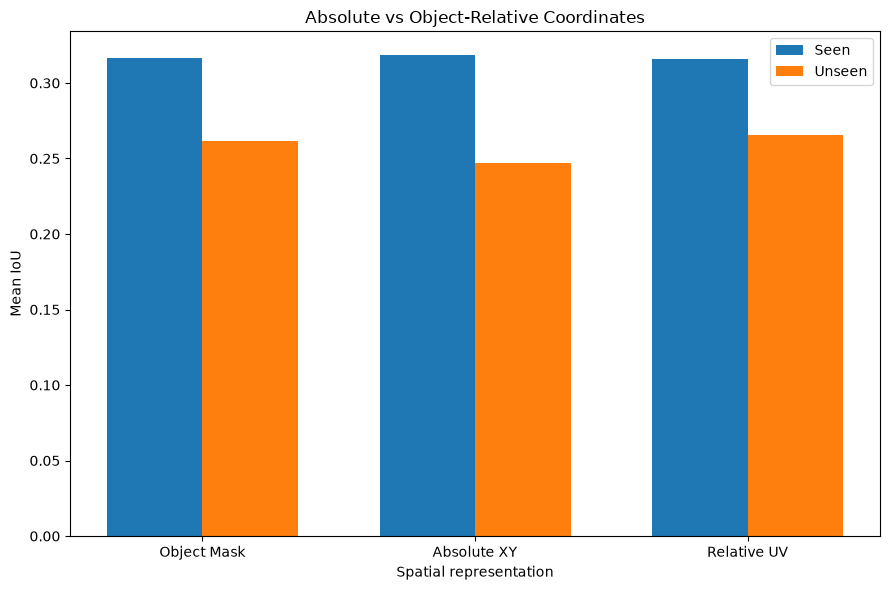

In [90]:
if geometry_results is not None:

    plot_data = (
        geometry_results.copy()
    )


    x = np.arange(
        len(plot_data)
    )


    width = 0.35


    plt.figure(
        figsize=(9, 6)
    )


    plt.bar(
        x - width / 2,
        plot_data[
            "seen_iou"
        ],
        width,
        label="Seen",
    )


    plt.bar(
        x + width / 2,
        plot_data[
            "unseen_iou"
        ],
        width,
        label="Unseen",
    )


    plt.xticks(
        x,
        plot_data[
            "model"
        ]
    )


    plt.ylabel(
        "Mean IoU"
    )

    plt.xlabel(
        "Spatial representation"
    )

    plt.title(
        "Absolute vs Object-Relative Coordinates"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        FINAL_ROOT
        / "geometry_comparison.png",
        dpi=200,
        bbox_inches="tight",
    )


    plt.show()

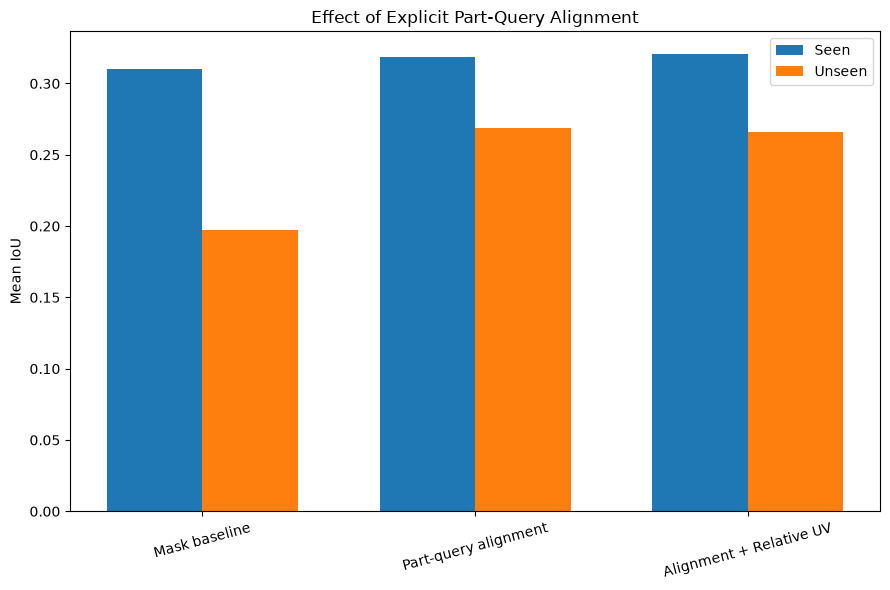

In [91]:
if alignment_results is not None:

    plot_data = (
        alignment_results.copy()
    )


    x = np.arange(
        len(plot_data)
    )


    width = 0.35


    plt.figure(
        figsize=(9, 6)
    )


    plt.bar(
        x - width / 2,
        plot_data[
            "seen_iou"
        ],
        width,
        label="Seen",
    )


    plt.bar(
        x + width / 2,
        plot_data[
            "unseen_iou"
        ],
        width,
        label="Unseen",
    )


    plt.xticks(
        x,
        plot_data[
            "model"
        ],
        rotation=15,
    )


    plt.ylabel(
        "Mean IoU"
    )

    plt.title(
        "Effect of Explicit Part-Query Alignment"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(
        FINAL_ROOT
        / "alignment_comparison.png",
        dpi=200,
        bbox_inches="tight",
    )


    plt.show()

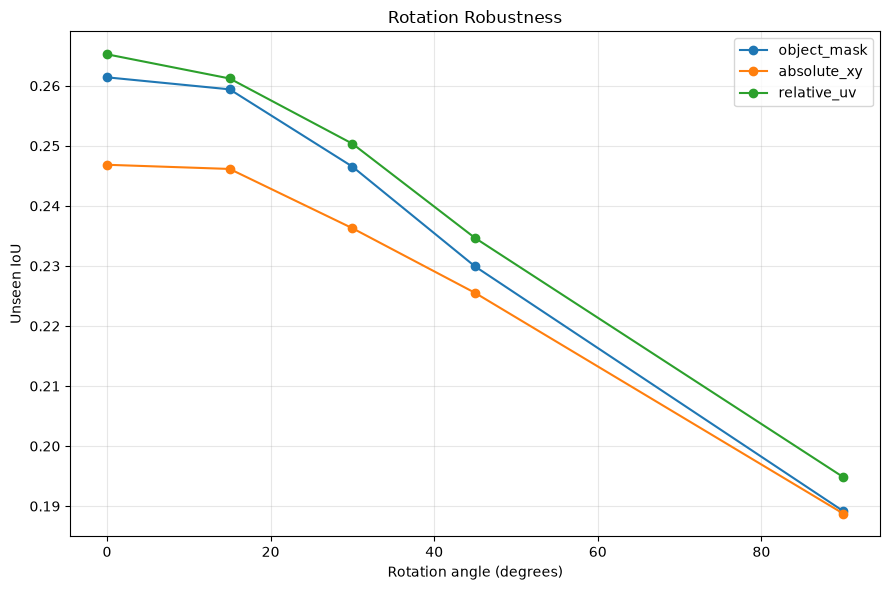

In [92]:
if rotation_results is not None:

    plt.figure(
        figsize=(9, 6)
    )


    for model in (
        unseen_rotation[
            "model"
        ].unique()
    ):

        subset = (
            unseen_rotation[
                unseen_rotation[
                    "model"
                ]
                == model
            ]
            .sort_values(
                "angle"
            )
        )


        plt.plot(
            subset[
                "angle"
            ],

            subset[
                "iou"
            ],

            marker="o",

            label=model,
        )


    plt.xlabel(
        "Rotation angle (degrees)"
    )

    plt.ylabel(
        "Unseen IoU"
    )

    plt.title(
        "Rotation Robustness"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(
        FINAL_ROOT
        / "rotation_robustness.png",
        dpi=200,
        bbox_inches="tight",
    )


    plt.show()

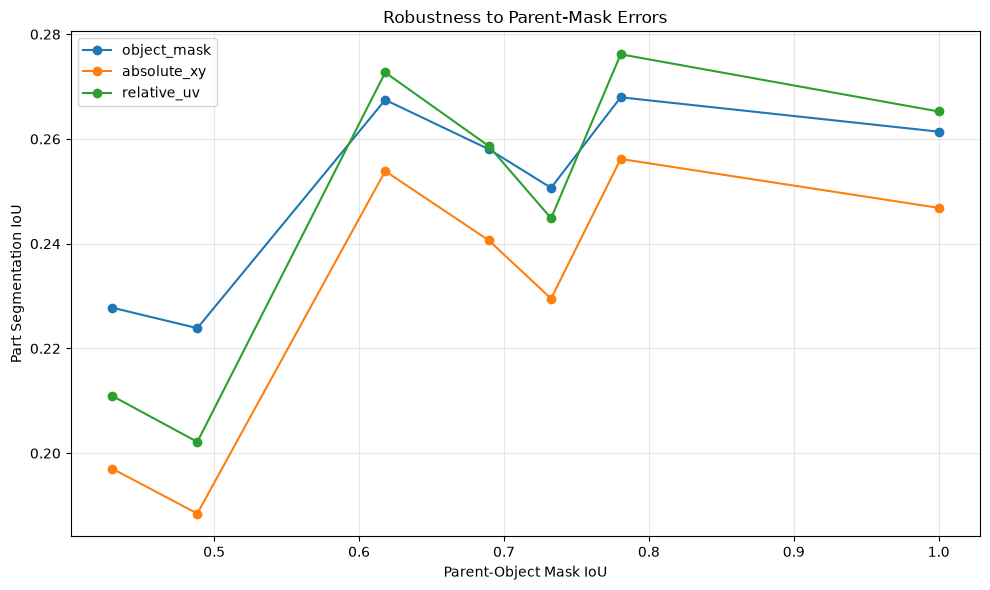

In [93]:
if mask_robustness_results is not None:

    plt.figure(
        figsize=(10, 6)
    )


    for model in (
        unseen_mask[
            "model"
        ].unique()
    ):

        subset = (
            unseen_mask[
                unseen_mask[
                    "model"
                ]
                == model
            ]
            .sort_values(
                "conditioning_mask_iou"
            )
        )


        plt.plot(
            subset[
                "conditioning_mask_iou"
            ],

            subset[
                "iou"
            ],

            marker="o",

            label=model,
        )


    plt.xlabel(
        "Parent-Object Mask IoU"
    )

    plt.ylabel(
        "Part Segmentation IoU"
    )

    plt.title(
        "Robustness to Parent-Mask Errors"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()


    plt.savefig(
        FINAL_ROOT
        / "mask_robustness.png",
        dpi=200,
        bbox_inches="tight",
    )


    plt.show()

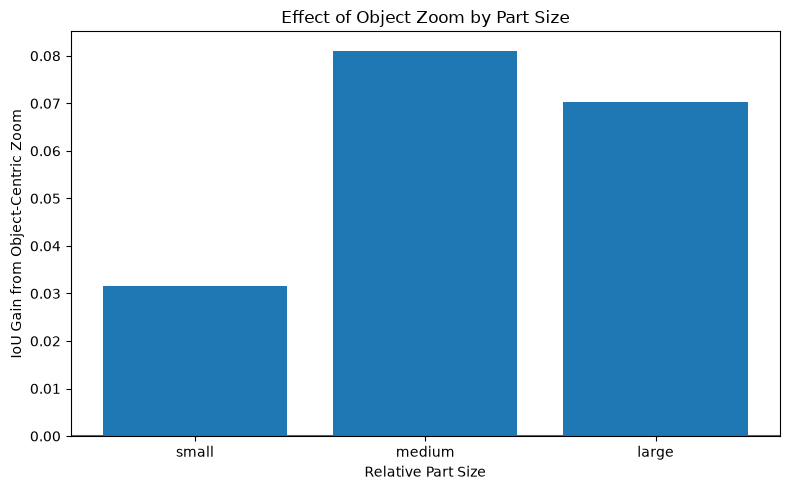

In [94]:
if part_size_summary is not None:

    plt.figure(
        figsize=(8, 5)
    )


    plt.bar(
        part_size_summary[
            "size_group"
        ],

        part_size_summary[
            "mean_gain"
        ],
    )


    plt.axhline(
        0
    )


    plt.xlabel(
        "Relative Part Size"
    )

    plt.ylabel(
        "IoU Gain from Object-Centric Zoom"
    )

    plt.title(
        "Effect of Object Zoom by Part Size"
    )

    plt.tight_layout()


    plt.savefig(
        FINAL_ROOT
        / "object_zoom_part_size.png",
        dpi=200,
        bbox_inches="tight",
    )


    plt.show()

In [95]:
final_summary = {

    "selected_model": {
        "name":
            FINAL_MODEL_NAME,

        "best_validation_iou":
            float(
                FINAL_MODEL_VAL_IOU
            ),

        "best_epoch":
            int(
                FINAL_MODEL_EPOCH
            ),
    }
}

if geometry_results is not None:

    final_summary[
        "geometry"
    ] = {

        "object_mask_unseen_iou":
            float(
                object_unseen
            ),

        "absolute_xy_unseen_iou":
            float(
                xy_unseen
            ),

        "relative_uv_unseen_iou":
            float(
                uv_unseen
            ),

        "relative_uv_vs_xy":
            float(
                uv_unseen
                - xy_unseen
            ),

        "relative_uv_vs_mask":
            float(
                uv_unseen
                - object_unseen
            ),

        "interpretation":
            geometry_interpretation,
    }

if alignment_results is not None:

    final_summary[
        "alignment"
    ] = {

        "baseline_unseen_iou":
            float(
                alignment_base
            ),

        "alignment_unseen_iou":
            float(
                alignment_only
            ),

        "alignment_uv_unseen_iou":
            float(
                alignment_uv
            ),

        "alignment_gain":
            float(
                alignment_gain
            ),

        "uv_gain_after_alignment":
            float(
                uv_after_alignment
            ),

        "interpretation":
            alignment_interpretation,
    }

if part_size_summary is not None:

    final_summary[
        "object_zoom"
    ] = {

        "small_part_gain":
            float(
                small_gain
            )
            if "small_gain"
            in globals()
            else None,

        "large_part_gain":
            float(
                large_gain
            )
            if "large_gain"
            in globals()
            else None,
    }

In [96]:
with open(
    FINAL_ROOT
    / "final_summary.json",
    "w",
) as f:

    json.dump(
        final_summary,
        f,
        indent=2,
    )


print(
    "Saved:",
    FINAL_ROOT
    / "final_summary.json"
)

Saved: /home/utn/ojug99ek/Computer_Vision_Object-Relative-Spatial-Encoding-for-Open-Vocabulary-Part-Segmentation/outputs/experiments/final_analysis/final_summary.json


In [97]:
conclusions = []

if baseline_results is not None:

    if mask_unseen_gain > 0:

        conclusions.append(
            f"Parent-object conditioning improved unseen "
            f"IoU by {mask_unseen_gain:+.4f} compared with "
            f"the DINO+CLIP baseline."
        )

    else:

        conclusions.append(
            f"Parent-object conditioning did not improve "
            f"the unseen baseline "
            f"({mask_unseen_gain:+.4f} IoU)."
        )

if geometry_results is not None:

    conclusions.append(
        geometry_interpretation
    )

if alignment_results is not None:

    conclusions.append(
        alignment_interpretation
    )

if (
    part_size_summary is not None
    and "small_gain"
    in globals()
):

    if small_gain > 0:

        conclusions.append(
            f"Object-centric zoom improved small-part IoU "
            f"by an average of {small_gain:+.4f}."
        )

    else:

        conclusions.append(
            f"Object-centric zoom did not improve small-part "
            f"segmentation ({small_gain:+.4f} IoU)."
        )


for i, conclusion in enumerate(
    conclusions,
    start=1,
):

    print(
        f"{i}. {conclusion}"
    )

1. Parent-object conditioning improved unseen IoU by +0.0735 compared with the DINO+CLIP baseline.
2. The geometry results are mixed and should be interpreted together with the robustness tests.
3. Explicit part-query alignment improves segmentation, while Relative UV adds little afterward. This suggests semantic grounding is a more important bottleneck than missing coordinate information.
4. Object-centric zoom improved small-part IoU by an average of +0.0316.


In [98]:
with open(
    FINAL_ROOT
    / "conclusions.txt",
    "w",
) as f:

    for conclusion in conclusions:

        f.write(
            conclusion
            + "\n"
        )

# Research Questions

## RQ1 — Does parent-object conditioning help?

Compare:

DINO + CLIP

against

DINO + CLIP + Parent Mask

This establishes whether explicit object context is useful.

---

## RQ2 — Does explicit geometry help beyond DINOv2?

Compare:

Object Mask

against

Absolute XY

and

Relative UV

This determines whether DINOv2 already contains sufficient spatial
information.

---

## RQ3 — Is object-relative geometry better than absolute image position?

Compare:

Absolute XY

against

Relative UV

This directly evaluates the central object-relative coordinate hypothesis.

---

## RQ4 — Is object-relative geometry robust?

Evaluate:

- rotation
- mask erosion
- mask dilation
- mask translation

This identifies whether U/V introduces orientation or mask-quality
sensitivity.

---

## RQ5 — Does explicit DINO–CLIP part-query correspondence help?

Compare:

Mask Baseline

against

Part-Query Alignment

This measures whether fine-grained visual-language grounding is a major
bottleneck.

---

## RQ6 — Is geometry complementary to improved semantic alignment?

Compare:

Part-Query Alignment

against

Alignment + Relative UV

If U/V still improves performance, spatial geometry and semantic alignment
provide complementary information.

---

## RQ7 — Is DINO's spatial resolution limiting small-part segmentation?

Compare:

Full image

against

Object-centric crop

and analyze performance according to part size.

This tests whether allocating more DINO patches to the selected object
improves fine-grained segmentation.

# Limitations

## Parent-object masks

The main method assumes access to a parent-object mask.

In a real system this mask may come from another segmentation or detection
model and may contain errors.

The mask-robustness experiment partially studies this limitation.

---

## Frozen foundation models

DINOv2 and CLIP remain frozen.

This keeps the system lightweight and makes the ablations easier to
interpret, but may limit task-specific adaptation.

---

## Spatial resolution

DINOv2 ViT-S/14 produces only a 16 × 16 feature grid at 224 × 224 input
resolution.

Tiny parts may therefore be poorly represented.

Object-centric zoom investigates this limitation.

---

## Orientation

Axis-aligned U/V coordinates are not rotation invariant.

The rotation experiment measures this failure mode directly.

---

## Dataset scope

Pascal-Part-116 contains a limited set of object and part categories.

Results therefore do not automatically imply generalization to arbitrary
open-world objects and part vocabularies.

---

## Experimental variance

Most experiments currently use one fixed random seed.

Small differences should therefore be interpreted cautiously.

Repeated training runs would be needed to characterize variance reliably.

---

## Text prompts

The current CLIP query uses a fixed prompt template.

Alternative prompt formulations or prompt ensembles were not extensively
studied.

In [99]:
print(
    "FINAL ANALYSIS FILES"
)

print(
    "--------------------"
)


for path in sorted(
    FINAL_ROOT.iterdir()
):

    print(
        path.name
    )

FINAL ANALYSIS FILES
--------------------
alignment_comparison.png
conclusions.txt
controlled_ablation_table.csv
final_report_results.csv
final_summary.json
geometry_comparison.png
hypothesis_summary.csv
mask_robustness.png
model_selection_validation.csv
object_zoom_part_size.png
rotation_robustness.png


# Final Project Status

## Data

- Pascal-Part-116 preparation ✓
- query-level manifests ✓
- seen/unseen split ✓
- dataset inspection ✓
- EDA ✓

## Foundation Models

- frozen DINOv2 ✓
- frozen CLIP ✓
- patch-feature analysis ✓
- text-embedding analysis ✓

## Baselines

- DINO + CLIP ✓
- DINO + CLIP + parent-object mask ✓

## Geometry Study

- object mask only ✓
- absolute X/Y ✓
- relative U/V ✓

## Robustness

- rotation ✓
- mask erosion ✓
- mask dilation ✓
- mask translation ✓

## Semantic Alignment

- explicit DINO–CLIP part-query alignment ✓
- alignment heatmaps ✓
- alignment auxiliary supervision ✓

## Fine-Grained Resolution

- object-centric crop ✓
- crop-to-full coordinate projection ✓
- DINO patch-resolution analysis ✓
- small/medium/large part analysis ✓

## Final Analysis

- validation-based model selection ✓
- seen/unseen comparison ✓
- controlled ablations ✓
- robustness analysis ✓
- hypothesis analysis ✓
- report-ready tables ✓
- report-ready plots ✓
- limitations ✓

No additional architecture should be added until these existing results
have been carefully interpreted.